# YouTube Toxic Comment Classification

## Part 1 — Introduction

### Student details

- IdoM — ID ending: [8349]
- ShirZ — ID ending: [4811]
- RoeeS — ID ending: [5498]

### AI prompts and additional resources

| Tool or resource | Prompt | Purpose |
|---|---|---|
| ChatGPT / Codex | "Why should the additional toxicity-label columns be excluded when `IsToxic` is the prediction target?" | Understanding and preventing target leakage. |
| ChatGPT / Codex | "Why is F1 for the toxic class more informative than accuracy for this task?" | Justifying the selected quality metric. |
| ChatGPT / Codex | "When removing English stop words, why should words such as `not`, `no`, and `never` be preserved?" | Preserving negation information during text preprocessing. |
| ChatGPT / Codex | "How do `C` and the learning rate affect logistic regression with L2 regularization and gradient descent?" | Understanding the tuned hyperparameters. |
| ChatGPT / Codex | "Why must text preprocessing and TF-IDF fitting occur separately inside every cross-validation fold?" | Avoiding validation leakage during grid search. |
| ChatGPT / Codex | "How can logistic-regression coefficients and TF-IDF-weighted contributions explain global and individual predictions?" | Understanding the explainability analysis. |
| Kaggle | https://www.kaggle.com/datasets/reihanenamdari/youtube-toxicity-data | Dataset source. |

### Learning problem and dataset

This project addresses a supervised binary text-classification problem: predicting whether an English YouTube comment is toxic. The input is the comment from the `Text` column, and the target is `IsToxic`, where `TRUE` represents a toxic comment and `FALSE` represents a non-toxic comment. The selected Kaggle dataset contains 1,000 manually labelled YouTube comments and additional labels describing different toxicity categories.

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

### Loading the train and test sets

The selected Kaggle dataset contains one CSV file rather than predefined train and test files. Therefore, the data is divided once using a fixed, stratified 80/20 split. Exact duplicate comments are removed before the split so the same text cannot appear in both sets. The test set is kept separate and will be used only for the final evaluation.

In [33]:
raw_df = pd.read_csv("youtoxic_english_1000.csv")

df = raw_df[["CommentId", "VideoId", "Text", "IsToxic"]].copy()
df["IsToxic"] = (
    df["IsToxic"]
    .astype(str)
    .str.upper()
    .map({"FALSE": 0, "TRUE": 1})
)

duplicate_key = (
    df["Text"]
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df = df.loc[~duplicate_key.duplicated()].reset_index(drop=True)

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["IsToxic"],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [34]:
train_df.head(5)

,CommentId,VideoId,Text,IsToxic
0,UgjVBYXVv7PQf3gCoAEC,04kJtp6pVXI,Why the hell are they even interviewing him? T...,1
1,UggAEGisedsvsXgCoAEC,9pr1oE34bIM,What injuries did the cop get treated for?,0
2,UghowP95HYyzrXgCoAEC,cT14IbTDW2c,2:22 a piece of shit that has no business wear...,1
3,UggGSYZZ2Wh2cXgCoAEC,TZxEyoplYbI,"Muslims from the UK, are with our black brothe...",0
4,Ugjqg9qKsdKAwHgCoAEC,dG7mZQvaQDk,Peggy you should watch life leadership revolut...,0


In [35]:
test_df.head(5)

,CommentId,VideoId,Text,IsToxic
0,UgjAHCc0hQVZ33gCoAEC,cT14IbTDW2c,some of us have jobs you fucking losers. Get o...,1
1,Ugi1CjkwLYHcvHgCoAEC,04kJtp6pVXI,"That motherfucker was angry,and I understand why",1
2,Ugw1DPfPxRKkqstwYSF4AaABAg,cT14IbTDW2c,The only time I'd want to see a sniper in the ...,1
3,UghAbXMwBZQ043gCoAEC,dDbRyFIkNII,the people in ferguson have to loot! the oly t...,1
4,Ugg8-b12nbu2-XgCoAEC,9pr1oE34bIM,You perform a basic snatch and grab robbery at...,1


# Quality metric

This is a binary classification problem with one central class: toxic comments. Therefore, according to the assignment instructions, model quality will be evaluated using the F1 score for the toxic class only (`IsToxic = 1`).

The F1 score combines precision and recall. Precision measures how many of the comments predicted as toxic are actually toxic, while recall measures how many of the truly toxic comments were correctly identified. This is appropriate for the current task because both failing to detect a toxic comment and incorrectly flagging a non-toxic comment are important errors.

The F1 score is calculated as:

$$
F1 = 2 \cdot \frac{\mathrm{Precision} \cdot \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}
$$

The same metric will be used throughout cross-validation, hyperparameter selection, and final test-set evaluation.

In [36]:
from sklearn.metrics import f1_score

def calculate_quality(y_true, y_pred):
    """Calculate the F1 score for the toxic class."""
    return f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0,
    )

# Part 2 — Feature Engineering

## Text preprocessing

Machine-learning algorithms cannot process raw text directly. Therefore, the comments must first be normalized and tokenized.

The preprocessing includes conversion to lowercase, removal of HTML tags and URLs, and tokenization. Stop-word removal and Porter stemming are optional operations whose effect will later be evaluated using 5-fold cross-validation. Negation words such as `not`, `no`, and `never` are preserved because removing them may change the meaning of a sentence.

The original comments remain unchanged. Only the text supplied to the feature-extraction stage is transformed.

In [37]:
import html
import re
import numpy as np

from nltk.stem import PorterStemmer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

porter_stemmer = PorterStemmer()
negation_words = {"no", "nor", "not", "never"}
safe_stop_words = set(ENGLISH_STOP_WORDS) - negation_words


class TextPreprocessor(BaseEstimator, TransformerMixin):
    """Clean and normalize English comments."""

    def __init__(self, remove_stopwords=False, use_stemming=False):
        self.remove_stopwords = remove_stopwords
        self.use_stemming = use_stemming

    def fit(self, X, y=None):
        return self

    def clean_comment(self, text):
        text = html.unescape(str(text)).lower()
        text = re.sub(r"<[^>]+>", " ", text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"\bcan't\b", "can not", text)
        text = re.sub(r"\bwon't\b", "will not", text)
        text = re.sub(r"n't\b", " not", text)
        tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", text)

        if self.remove_stopwords:
            tokens = [token for token in tokens if token not in safe_stop_words]

        if self.use_stemming:
            tokens = [porter_stemmer.stem(token) for token in tokens]

        return " ".join(tokens)

    def transform(self, X):
        return [self.clean_comment(text) for text in X]

The preprocessing procedure is demonstrated on three comments from the training set and three comments from the test set. For each comment, basic preprocessing, stop-word removal, and Porter stemming are presented. The test examples are transformed only for demonstration and are not used to learn a vocabulary or select preprocessing parameters.

In [38]:
basic_preprocessor = TextPreprocessor(
    remove_stopwords=False,
    use_stemming=False,
)

stopword_preprocessor = TextPreprocessor(
    remove_stopwords=True,
    use_stemming=False,
)

stemming_preprocessor = TextPreprocessor(
    remove_stopwords=True,
    use_stemming=True,
)

selected_train_indices = train_df.sample(n=3, random_state=42).index.tolist()
selected_test_indices = test_df.sample(n=3, random_state=42).index.tolist()

### Three preprocessing examples from the train and test sets

In [39]:
def create_preprocessing_examples(source_df, row_indices, dataset_name):
    examples = source_df.loc[row_indices, ["Text", "IsToxic"]].copy()
    examples.insert(0, "Dataset", dataset_name)
    examples["Basic preprocessing"] = basic_preprocessor.transform(examples["Text"])
    examples["Without stop words"] = stopword_preprocessor.transform(examples["Text"])
    examples["With Porter stemming"] = stemming_preprocessor.transform(examples["Text"])
    return examples.reset_index(drop=True)


train_preprocessing_examples = create_preprocessing_examples(
    train_df, selected_train_indices, "Train"
)
test_preprocessing_examples = create_preprocessing_examples(
    test_df, selected_test_indices, "Test"
)

display(pd.concat(
    [train_preprocessing_examples, test_preprocessing_examples],
    ignore_index=True,
))

,Dataset,Text,IsToxic,Basic preprocessing,Without stop words,With Porter stemming
0,Train,"If Michael Brown was Asian, his name would be ...",1,if michael brown was asian his name would be d...,michael brown asian dindu nuffin wong,michael brown asian dindu nuffin wong
1,Train,Great video...Thank you Peggy.,0,great video thank you peggy,great video thank peggy,great video thank peggi
2,Train,Sure...they totally looked at FACTUAL evidence...,1,sure they totally looked at factual evidence d...,sure totally looked factual evidence trial lik...,sure total look factual evid trial like specia...
3,Test,That video of him pushing that clerk around re...,1,that video of him pushing that clerk around re...,video pushing clerk really lose sympathy defin...,video push clerk realli lose sympathi definit ...
4,Test,"Dude someone, please tell this dude that liste...",0,dude someone please tell this dude that listen...,dude tell dude listen violent music like gangs...,dude tell dude listen violent music like gangs...
5,Test,Muslims like to spit on white people.\nBrought...,1,muslims like to spit on white people brought i...,muslims like spit white people brought muslims...,muslim like spit white peopl brought muslim ng...


## TF-IDF feature extraction

After preprocessing, the comments are converted into numerical feature vectors using TF-IDF. Term Frequency measures how frequently a term occurs in a particular comment. Inverse Document Frequency reduces the weight of terms that occur in many training comments and increases the relative importance of less common terms.

$$\operatorname{TFIDF}(t,d)=\operatorname{TF}(t,d)\cdot\operatorname{IDF}(t)$$

The representation includes unigrams and bigrams. Unigrams represent individual words, while bigrams represent pairs of adjacent words and preserve limited local context. Sublinear term frequency is applied so repeated appearances of a term do not increase its influence linearly. L2 normalization scales every comment vector to unit length.

The vectorizer is fitted on the training set only. The test set is transformed using the vocabulary and IDF values learned from the training set.

Stop-word removal, Porter stemming, and the TF-IDF n-gram range will be compared systematically using grid search with 5-fold cross-validation in Part 6A.

In [40]:
processed_train_text = basic_preprocessor.transform(train_df["Text"])
processed_test_text = basic_preprocessor.transform(test_df["Text"])

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm="l2",
)

X_train_tfidf = tfidf_vectorizer.fit_transform(processed_train_text)
X_test_tfidf = tfidf_vectorizer.transform(processed_test_text)

print("Train feature matrix shape:", X_train_tfidf.shape)
print("Test feature matrix shape:", X_test_tfidf.shape)

Train feature matrix shape: (796, 21361)
Test feature matrix shape: (199, 21361)


### TF-IDF examples

For each example, the following function displays the original comment and the eight features with the highest non-zero TF-IDF weights. Each feature represents either one word or a pair of adjacent words.

In [41]:
def show_tfidf_examples(source_df, feature_matrix, vectorizer, row_indices, dataset_name, top_n=8):
    feature_names = vectorizer.get_feature_names_out()
    result_rows = []

    for row_index in row_indices:
        feature_row = feature_matrix.getrow(row_index)
        sorted_positions = np.argsort(feature_row.data)[::-1][:top_n]
        highest_features = []

        for position in sorted_positions:
            feature_index = feature_row.indices[position]
            feature_name = feature_names[feature_index]
            feature_value = feature_row.data[position]
            highest_features.append(f"{feature_name}: {feature_value:.3f}")

        result_rows.append({
            "Dataset": dataset_name,
            "IsToxic": source_df.loc[row_index, "IsToxic"],
            "Text": source_df.loc[row_index, "Text"],
            "Highest TF-IDF features": ", ".join(highest_features),
        })

    return pd.DataFrame(result_rows)

### Three train-set examples

In [42]:
train_tfidf_examples = show_tfidf_examples(
    train_df,
    X_train_tfidf,
    tfidf_vectorizer,
    selected_train_indices,
    "Train",
)
display(train_tfidf_examples)

,Dataset,IsToxic,Text,Highest TF-IDF features
0,Train,1,"If Michael Brown was Asian, his name would be ...","nuffin wong: 0.256, dindu nuffin: 0.256, be di..."
1,Train,0,Great video...Thank you Peggy.,"video thank: 0.467, you peggy: 0.420, great vi..."
2,Train,1,Sure...they totally looked at FACTUAL evidence...,"happen did: 0.169, all knew: 0.169, knew that:..."


### Three test-set examples

In [43]:
test_tfidf_examples = show_tfidf_examples(
    test_df,
    X_test_tfidf,
    tfidf_vectorizer,
    selected_test_indices,
    "Test",
)
display(test_tfidf_examples)

,Dataset,IsToxic,Text,Highest TF-IDF features
0,Test,1,That video of him pushing that clerk around re...,"that video: 0.178, one in: 0.178, riot and: 0...."
1,Test,0,"Dude someone, please tell this dude that liste...","dude: 0.334, or killing: 0.252, like fighting:..."
2,Test,1,Muslims like to spit on white people.\nBrought...,"muslims: 0.403, spit: 0.238, spit on: 0.238, s..."


# Part 3 — Learning Algorithm Implementation

## Logistic Regression

Logistic regression is a supervised binary-classification algorithm. For every TF-IDF comment vector $x$, the model first calculates a linear score:

$$z = w^T x + b$$

The sigmoid function converts the score into a probability between 0 and 1:

$$P(y=1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}}$$

Here, $P(y=1\mid x)$ is the estimated probability that a comment is toxic. A probability greater than or equal to the decision threshold is classified as toxic.

The parameters are learned by minimizing binary cross-entropy with L2 regularization:

$$J(w,b)=-\frac{1}{m}\sum_{i=1}^{m}\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right]+\frac{1}{2Cm}\lVert w\rVert_2^2$$

Batch gradient descent repeatedly updates the weights and intercept in the direction that reduces this loss:

$$w \leftarrow w-\alpha\frac{\partial J}{\partial w},\qquad b \leftarrow b-\alpha\frac{\partial J}{\partial b}$$

The implementation below was written for this assignment and does not use `sklearn.linear_model.LogisticRegression`. It supports sparse TF-IDF matrices and provides separate `fit`, `predict_proba`, and `predict` methods.

### Hyperparameters

- `learning_rate` controls the size of each gradient-descent update. A value that is too small causes slow learning, while a value that is too large may prevent convergence.
- `max_iter` is the maximum number of gradient-descent iterations.
- `C` is the inverse L2-regularization strength. Smaller values produce stronger regularization.
- `threshold` converts the predicted probability into class 0 or 1.
- `tol` is the minimum loss improvement required to continue training.

Different values will later be evaluated using 5-fold cross-validation and the F1 score of the toxic class.

In [44]:
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted


class CustomLogisticRegression(ClassifierMixin, BaseEstimator):
    """Binary logistic regression trained with batch gradient descent."""

    def __init__(
        self,
        learning_rate=0.5,
        max_iter=1000,
        C=1.0,
        threshold=0.5,
        tol=1e-7,
    ):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.C = C
        self.threshold = threshold
        self.tol = tol

    @staticmethod
    def _sigmoid(scores):
        scores = np.clip(scores, -500, 500)
        return 1.0 / (1.0 + np.exp(-scores))

    def _validate_hyperparameters(self):
        if self.learning_rate <= 0:
            raise ValueError("learning_rate must be positive.")
        if self.max_iter <= 0:
            raise ValueError("max_iter must be positive.")
        if self.C <= 0:
            raise ValueError("C must be positive.")
        if not 0 < self.threshold < 1:
            raise ValueError("threshold must be between 0 and 1.")
        if self.tol < 0:
            raise ValueError("tol cannot be negative.")

    def fit(self, X, y):
        """Learn the weights and intercept from labelled training examples."""
        self._validate_hyperparameters()
        X = sparse.csr_matrix(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).reshape(-1)

        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must contain the same number of examples.")
        if not np.all(np.isin(y, [0.0, 1.0])):
            raise ValueError("Labels must be encoded as 0 and 1.")

        n_samples, n_features = X.shape
        self.n_features_in_ = n_features
        self.classes_ = np.array([0, 1])
        self.weights_ = np.zeros(n_features, dtype=np.float64)
        self.intercept_ = 0.0
        self.loss_history_ = []

        regularization_strength = 1.0 / (self.C * n_samples)
        previous_loss = np.inf

        for iteration in range(self.max_iter):
            scores = np.asarray(X @ self.weights_).reshape(-1) + self.intercept_
            probabilities = self._sigmoid(scores)
            errors = probabilities - y

            weight_gradient = np.asarray(X.T @ errors).reshape(-1) / n_samples
            weight_gradient += regularization_strength * self.weights_
            intercept_gradient = errors.mean()

            self.weights_ -= self.learning_rate * weight_gradient
            self.intercept_ -= self.learning_rate * intercept_gradient

            updated_scores = np.asarray(X @ self.weights_).reshape(-1) + self.intercept_
            data_loss = np.mean(
                np.logaddexp(0.0, updated_scores) - y * updated_scores
            )
            penalty = 0.5 * regularization_strength * np.dot(
                self.weights_, self.weights_
            )
            current_loss = data_loss + penalty
            self.loss_history_.append(current_loss)

            if abs(previous_loss - current_loss) < self.tol:
                break
            previous_loss = current_loss

        self.n_iter_ = iteration + 1
        self.coef_ = self.weights_.reshape(1, -1)
        return self

    def decision_function(self, X):
        """Return the linear score for each example."""
        check_is_fitted(self, ["weights_", "intercept_"])
        X = sparse.csr_matrix(X, dtype=np.float64)

        if X.shape[1] != self.n_features_in_:
            raise ValueError(
                "X has a different number of features than the training data."
            )

        return np.asarray(X @ self.weights_).reshape(-1) + self.intercept_

    def predict_proba(self, X):
        """Return probabilities for the non-toxic and toxic classes."""
        toxic_probability = self._sigmoid(self.decision_function(X))
        return np.column_stack([
            1.0 - toxic_probability,
            toxic_probability,
        ])

    def predict(self, X):
        """Predict 1 for toxic and 0 for non-toxic comments."""
        toxic_probability = self.predict_proba(X)[:, 1]
        return (toxic_probability >= self.threshold).astype(int)

### Implementation check on the training set

The next cell verifies that the implementation can train and predict, that all returned probabilities are valid, and that the loss decreases during optimization. This is only a technical check on the training set. It is not used to estimate final model quality or select hyperparameters, and the test set remains untouched.

In [45]:
initial_model = CustomLogisticRegression(
    learning_rate=0.5,
    max_iter=1000,
    C=1.0,
    threshold=0.5,
    tol=1e-7,
)

initial_model.fit(
    X_train_tfidf,
    train_df["IsToxic"],
)

initial_train_probabilities = initial_model.predict_proba(X_train_tfidf)
initial_train_predictions = initial_model.predict(X_train_tfidf)

assert initial_train_probabilities.shape == (len(train_df), 2)
assert np.all((initial_train_probabilities >= 0) & (initial_train_probabilities <= 1))
assert np.allclose(initial_train_probabilities.sum(axis=1), 1.0)
assert set(np.unique(initial_train_predictions)).issubset({0, 1})
assert initial_model.loss_history_[-1] < initial_model.loss_history_[0]

print("Iterations performed:", initial_model.n_iter_)
print("Initial loss:", round(initial_model.loss_history_[0], 6))
print("Final loss:", round(initial_model.loss_history_[-1], 6))
print("Implementation checks passed successfully.")

Iterations performed: 1000
Initial loss: 0.692174
Final loss: 0.59253
Implementation checks passed successfully.


In [46]:
training_prediction_examples = train_df.loc[:4, ["Text", "IsToxic"]].copy()
training_prediction_examples["Toxic probability"] = (
    initial_train_probabilities[:5, 1].round(4)
)
training_prediction_examples["Prediction"] = initial_train_predictions[:5]
display(training_prediction_examples)

,Text,IsToxic,Toxic probability,Prediction
0,Why the hell are they even interviewing him? T...,1,0.5618,1
1,What injuries did the cop get treated for?,0,0.4170,0
2,2:22 a piece of shit that has no business wear...,1,0.5696,1
3,"Muslims from the UK, are with our black brothe...",0,0.4304,0
4,Peggy you should watch life leadership revolut...,0,0.3818,0


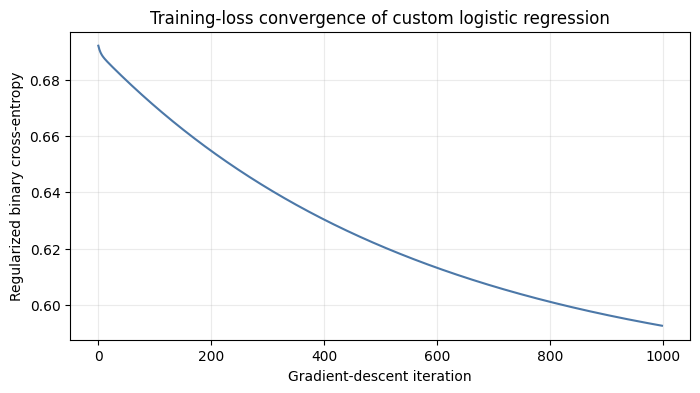

In [47]:
plt.figure(figsize=(8, 4))
plt.plot(initial_model.loss_history_, color="#4C78A8")
plt.xlabel("Gradient-descent iteration")
plt.ylabel("Regularized binary cross-entropy")
plt.title("Training-loss convergence of custom logistic regression")
plt.grid(alpha=0.25)
plt.show()

The decreasing loss shows that gradient descent updates the parameters in the intended direction. The model has not yet been evaluated on the test set. Hyperparameter and feature-engineering combinations will first be compared using cross-validation on the training set. The selected configuration will then be retrained on the complete training set.

# Part 6A — Extension: Feature Engineering and Hyperparameter Tuning

This extension is placed before Part 4 because its winning configuration will be used there to retrain the model on the complete training set. The held-out test set is not used anywhere during model selection.

## Experimental design

The extension compares three feature-engineering choices and two logistic-regression hyperparameters:

- Stop-word removal: `False`, `True`
- Porter stemming: `False`, `True`
- TF-IDF n-grams: unigrams `(1, 1)` or unigrams and bigrams `(1, 2)`
- Regularization parameter `C`: `0.1`, `1.0`, `10.0`
- Gradient-descent learning rate: `0.1`, `0.5`

The Cartesian product contains $2 \times 2 \times 2 \times 3 \times 2 = 48$ configurations. Each configuration is evaluated with stratified 5-fold cross-validation, producing 240 model fits. In every fold, four parts are used for fitting and the remaining part is used for validation. The reported quality is the mean F1 score of the toxic class across the five validation folds.

A `Pipeline` wraps preprocessing, TF-IDF, and logistic regression. Therefore, the vocabulary and IDF values are learned only from the four training folds on every run, preventing validation leakage.

In [48]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer

toxic_f1_scorer = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0,
)

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

## Grid search with 5-fold cross-validation

The following cell runs all 48 configurations. The 240 fits may take several minutes. `refit=False` is used because Part 4 will explicitly train a new model on the complete training set with the winning configuration.

In [18]:
extension_pipeline = Pipeline([
    ("preprocess", TextPreprocessor()),
    ("tfidf", TfidfVectorizer(
        sublinear_tf=True,
        norm="l2",
    )),
    ("model", CustomLogisticRegression(
        max_iter=1000,
        threshold=0.5,
        tol=1e-7,
    )),
])

extension_parameter_grid = {
    "preprocess__remove_stopwords": [False, True],
    "preprocess__use_stemming": [False, True],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "model__C": [0.1, 1.0, 10.0],
    "model__learning_rate": [0.1, 0.5],
}

grid_search = GridSearchCV(
    estimator=extension_pipeline,
    param_grid=extension_parameter_grid,
    scoring=toxic_f1_scorer,
    cv=cross_validation,
    refit=False,
    n_jobs=-1,
    return_train_score=False,
    verbose=1,
)

grid_search.fit(
    train_df["Text"],
    train_df["IsToxic"],
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess', TextPreprocessor()),
                                       ('tfidf',
                                        TfidfVectorizer(sublinear_tf=True)),
                                       ('model', CustomLogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1.0, 10.0],
                         'model__learning_rate': [0.1, 0.5],
                         'preprocess__remove_stopwords': [False, True],
                         'preprocess__use_stemming': [False, True],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             refit=False,
             scoring=make_scorer(f1_score, response_method='predict', pos_label=1, zero_division=0),
             verbose=1)

## Results of all permutations

The table contains every tested permutation, its mean validation F1 over the five folds, the standard deviation between folds, and its rank. A high mean F1 indicates better toxic-comment detection; the standard deviation describes stability across the folds.

In [19]:
extension_results = pd.DataFrame({
    "remove_stopwords": grid_search.cv_results_[
        "param_preprocess__remove_stopwords"
    ],
    "use_stemming": grid_search.cv_results_[
        "param_preprocess__use_stemming"
    ],
    "ngram_range": grid_search.cv_results_[
        "param_tfidf__ngram_range"
    ],
    "C": grid_search.cv_results_["param_model__C"],
    "learning_rate": grid_search.cv_results_[
        "param_model__learning_rate"
    ],
    "mean_validation_F1": grid_search.cv_results_["mean_test_score"],
    "std_validation_F1": grid_search.cv_results_["std_test_score"],
    "rank": grid_search.cv_results_["rank_test_score"],
})

extension_results = (
    extension_results
    .sort_values(["rank", "std_validation_F1"])
    .reset_index(drop=True)
)

assert len(extension_results) == 48
display(extension_results.round({
    "mean_validation_F1": 4,
    "std_validation_F1": 4,
}))

,remove_stopwords,use_stemming,ngram_range,C,learning_rate,mean_validation_F1,std_validation_F1,rank
0,True,True,"(1, 1)",10.0,0.5,0.6309,0.0489,1
1,True,True,"(1, 2)",10.0,0.5,0.6277,0.0447,2
2,False,True,"(1, 1)",10.0,0.5,0.6159,0.0398,3
3,True,True,"(1, 1)",1.0,0.5,0.6104,0.0472,4
4,False,False,"(1, 1)",10.0,0.5,0.6099,0.0527,5
5,True,False,"(1, 1)",10.0,0.5,0.5959,0.0472,6
6,False,True,"(1, 1)",1.0,0.5,0.5871,0.0488,7
7,True,True,"(1, 2)",1.0,0.5,0.5670,0.0539,8
8,False,False,"(1, 1)",1.0,0.5,0.5642,0.0476,9
9,True,False,"(1, 2)",10.0,0.5,0.5633,0.0438,10


## Best permutation

The winning permutation and its mean cross-validation score are displayed separately, as required. These values will be used in Part 4 to rebuild the complete feature-engineering flow and train a fresh model on the entire training set.

In [20]:
best_result_index = int(np.argmax(grid_search.cv_results_["mean_test_score"]))
best_extension_parameters = grid_search.cv_results_["params"][
    best_result_index
]
best_cv_f1 = float(grid_search.cv_results_["mean_test_score"][
    best_result_index
])
best_cv_f1_std = float(grid_search.cv_results_["std_test_score"][
    best_result_index
])

best_permutation = pd.DataFrame([{
    "remove_stopwords": best_extension_parameters[
        "preprocess__remove_stopwords"
    ],
    "use_stemming": best_extension_parameters[
        "preprocess__use_stemming"
    ],
    "ngram_range": best_extension_parameters["tfidf__ngram_range"],
    "C": best_extension_parameters["model__C"],
    "learning_rate": best_extension_parameters[
        "model__learning_rate"
    ],
    "mean_5_fold_F1": best_cv_f1,
    "std_5_fold_F1": best_cv_f1_std,
}])

display(best_permutation.round({
    "mean_5_fold_F1": 4,
    "std_5_fold_F1": 4,
}))

,remove_stopwords,use_stemming,ngram_range,C,learning_rate,mean_5_fold_F1,std_5_fold_F1
0,True,True,"(1, 1)",10.0,0.5,0.6309,0.0489


### Interpretation

The selected configuration is based only on the average validation F1 across the five folds, not on the held-out test set. Consequently, Part 4 can use the selected preprocessing, TF-IDF settings, `C`, and learning rate to retrain on all training examples, while Part 5 can provide a single unbiased test evaluation.

## Why Part 6B was not selected

Part 6B proposes resampling methods for imbalanced data. This extension was not applied because the training set is already reasonably balanced: 430 comments (54.02%) are non-toxic and 366 comments (45.98%) are toxic. Applying over-sampling or under-sampling without a substantial imbalance could unnecessarily distort the observed data distribution or discard useful examples.

# Part 4 — Training with the Best Configuration

The best configuration found by the 5-fold grid search is now used to rebuild the complete flow. The preprocessor and TF-IDF vectorizer are fitted on the entire training set, and a new logistic-regression model is trained from the beginning. The test set remains untouched.

In [21]:
final_preprocessor = TextPreprocessor(
    remove_stopwords=best_extension_parameters[
        "preprocess__remove_stopwords"
    ],
    use_stemming=best_extension_parameters[
        "preprocess__use_stemming"
    ],
)

final_train_text = final_preprocessor.fit_transform(train_df["Text"])

final_vectorizer = TfidfVectorizer(
    ngram_range=best_extension_parameters["tfidf__ngram_range"],
    sublinear_tf=True,
    norm="l2",
)
X_final_train = final_vectorizer.fit_transform(final_train_text)

final_model = CustomLogisticRegression(
    C=best_extension_parameters["model__C"],
    learning_rate=best_extension_parameters["model__learning_rate"],
    max_iter=1000,
    threshold=0.5,
    tol=1e-7,
)
final_model.fit(X_final_train, train_df["IsToxic"])

selected_training_configuration = pd.DataFrame([{
    "remove_stopwords": final_preprocessor.remove_stopwords,
    "use_stemming": final_preprocessor.use_stemming,
    "ngram_range": final_vectorizer.ngram_range,
    "C": final_model.C,
    "learning_rate": final_model.learning_rate,
    "training_examples": X_final_train.shape[0],
    "number_of_features": X_final_train.shape[1],
    "iterations_performed": final_model.n_iter_,
    "final_training_loss": final_model.loss_history_[-1],
}])

display(selected_training_configuration.round({
    "final_training_loss": 6,
}))

,remove_stopwords,use_stemming,ngram_range,C,learning_rate,training_examples,number_of_features,iterations_performed,final_training_loss
0,True,True,"(1, 1)",10.0,0.5,796,2797,1000,0.502234


## Examples passing through the final feature-engineering flow

The following table follows three training comments through the selected feature-engineering flow. It presents the original text, the text after the winning preprocessing configuration, and the eight non-zero TF-IDF features with the highest weights. These numerical values are the inputs received by the final model.

In [22]:
def show_final_training_flow(row_indices, top_n=8):
    feature_names = final_vectorizer.get_feature_names_out()
    rows = []

    for row_index in row_indices:
        original_text = train_df.loc[row_index, "Text"]
        processed_text = final_preprocessor.transform([original_text])[0]
        feature_row = final_vectorizer.transform([processed_text]).getrow(0)
        sorted_positions = np.argsort(feature_row.data)[::-1][:top_n]

        top_features = []
        for position in sorted_positions:
            feature_index = feature_row.indices[position]
            top_features.append(
                f"{feature_names[feature_index]}: "
                f"{feature_row.data[position]:.3f}"
            )

        rows.append({
            "IsToxic": train_df.loc[row_index, "IsToxic"],
            "1. Original comment": original_text,
            "2. Processed comment": processed_text,
            "3. Highest TF-IDF features": ", ".join(top_features),
        })

    return pd.DataFrame(rows)

final_training_flow_examples = show_final_training_flow(
    selected_train_indices
)
display(final_training_flow_examples)

,IsToxic,1. Original comment,2. Processed comment,3. Highest TF-IDF features
0,1,"If Michael Brown was Asian, his name would be ...",michael brown asian dindu nuffin wong,"wong: 0.472, nuffin: 0.472, dindu: 0.472, asia..."
1,0,Great video...Thank you Peggy.,great video thank peggi,"great: 0.563, peggi: 0.535, thank: 0.470, vide..."
2,1,Sure...they totally looked at FACTUAL evidence...,sure total look factual evid trial like specia...,"treatment: 0.348, special: 0.327, factual: 0.3..."


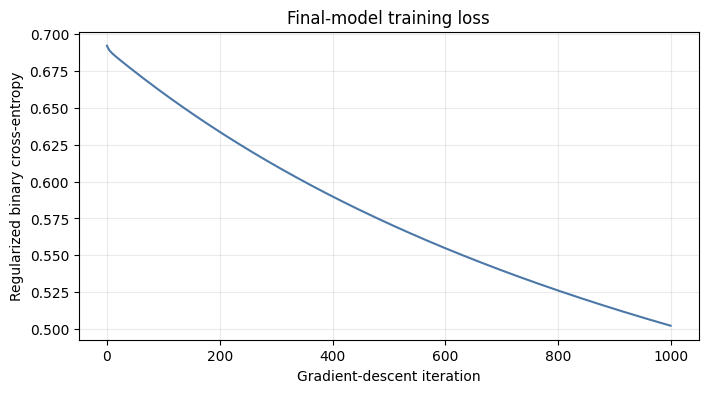

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(final_model.loss_history_, color="#4C78A8")
plt.xlabel("Gradient-descent iteration")
plt.ylabel("Regularized binary cross-entropy")
plt.title("Final-model training loss")
plt.grid(alpha=0.25)
plt.show()

# Part 6C — Explainability

Logistic regression is directly interpretable through its learned coefficients. For feature $j$, a positive coefficient $w_j$ increases the linear score and pushes the prediction toward the toxic class, while a negative coefficient pushes it toward the non-toxic class. A larger absolute coefficient represents a stronger effect, although the contribution to a particular comment also depends on that feature's TF-IDF value.

For an individual comment, the contribution of feature $j$ is $x_j w_j$. The contributions and intercept form the linear score $z=b+\sum_j x_jw_j$, which is converted into a toxic probability by the sigmoid function.

## Global explanation: most influential features

The table and graph show the features with the largest positive and negative coefficients. Positive coefficients are global indicators of toxic language according to the trained model; negative coefficients are global indicators of non-toxic language. They describe associations learned from this dataset and should not be interpreted as universal causal rules.

In [24]:
final_feature_names = final_vectorizer.get_feature_names_out()
final_coefficients = final_model.coef_[0]
number_of_global_features = 15

toxic_feature_indices = np.argsort(final_coefficients)[
    -number_of_global_features:
][::-1]
non_toxic_feature_indices = np.argsort(final_coefficients)[
    :number_of_global_features
]

global_feature_explanation = pd.DataFrame({
    "Toward toxic": final_feature_names[toxic_feature_indices],
    "Positive coefficient": final_coefficients[toxic_feature_indices],
    "Toward non-toxic": final_feature_names[non_toxic_feature_indices],
    "Negative coefficient": final_coefficients[non_toxic_feature_indices],
})
display(global_feature_explanation.round(4))

,Toward toxic,Positive coefficient,Toward non-toxic,Negative coefficient
0,fuck,2.6550,video,-1.3282
1,shit,1.8438,peggi,-1.2257
2,idiot,1.7659,thank,-1.0207
3,run,1.5426,truth,-0.9172
4,ass,1.4066,stefan,-0.8823
5,stupid,1.2975,not,-0.8338
6,dumb,0.9941,rap,-0.7790
7,thug,0.9727,pretti,-0.7190
8,bitch,0.9576,good,-0.7153
9,driver,0.7919,say,-0.6277


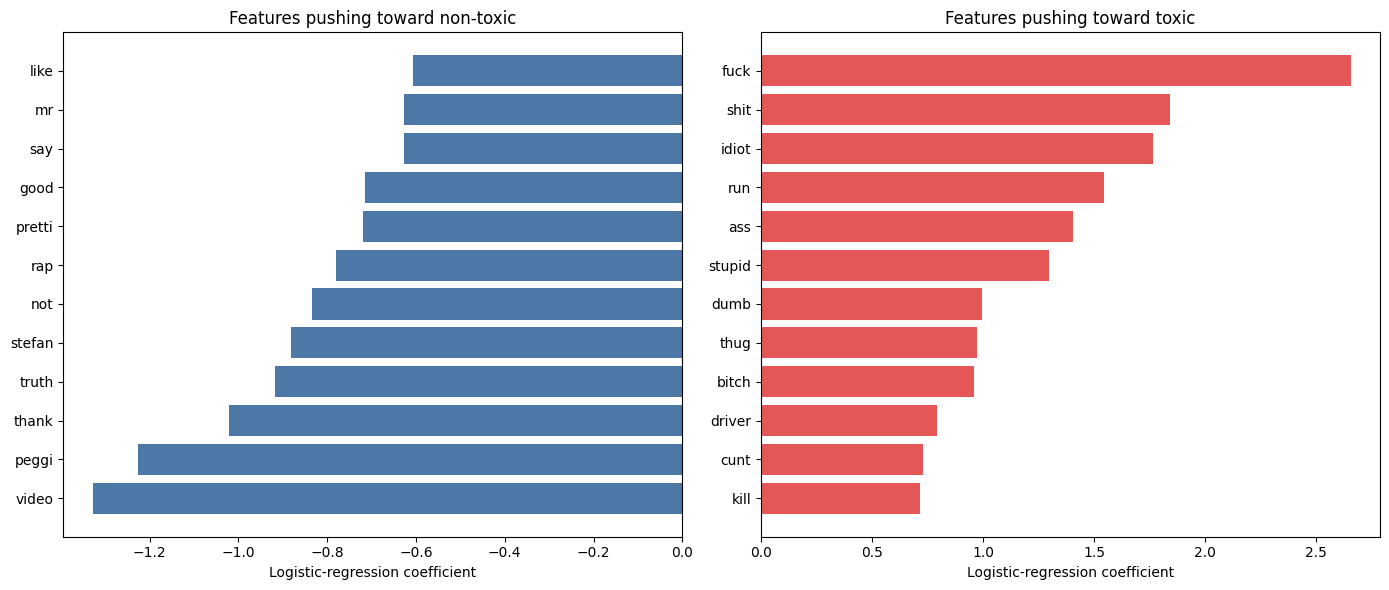

In [25]:
plot_count = 12
toxic_plot_indices = toxic_feature_indices[:plot_count][::-1]
non_toxic_plot_indices = non_toxic_feature_indices[:plot_count]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(
    final_feature_names[non_toxic_plot_indices],
    final_coefficients[non_toxic_plot_indices],
    color="#4C78A8",
)
axes[0].set_title("Features pushing toward non-toxic")
axes[0].set_xlabel("Logistic-regression coefficient")

axes[1].barh(
    final_feature_names[toxic_plot_indices],
    final_coefficients[toxic_plot_indices],
    color="#E45756",
)
axes[1].set_title("Features pushing toward toxic")
axes[1].set_xlabel("Logistic-regression coefficient")

plt.tight_layout()
plt.show()

## Local explanation of three training predictions

For each example, the next table displays the model prediction and the strongest feature contributions in both directions. This explains why the model assigned its probability to that specific comment rather than only describing the model globally.

In [26]:
def explain_training_predictions(row_indices, top_n=5):
    rows = []

    for row_index in row_indices:
        original_text = train_df.loc[row_index, "Text"]
        processed_text = final_preprocessor.transform([original_text])[0]
        feature_row = final_vectorizer.transform([processed_text]).getrow(0)
        toxic_probability = final_model.predict_proba(feature_row)[0, 1]
        prediction = final_model.predict(feature_row)[0]

        contributions = (
            feature_row.data * final_coefficients[feature_row.indices]
        )
        positive_positions = [
            position
            for position in np.argsort(contributions)[::-1]
            if contributions[position] > 0
        ][:top_n]
        negative_positions = [
            position
            for position in np.argsort(contributions)
            if contributions[position] < 0
        ][:top_n]

        toward_toxic = [
            f"{final_feature_names[feature_row.indices[position]]}: "
            f"{contributions[position]:.3f}"
            for position in positive_positions
        ]
        toward_non_toxic = [
            f"{final_feature_names[feature_row.indices[position]]}: "
            f"{contributions[position]:.3f}"
            for position in negative_positions
        ]

        rows.append({
            "True label": train_df.loc[row_index, "IsToxic"],
            "Prediction": prediction,
            "Toxic probability": toxic_probability,
            "Comment": original_text,
            "Strongest contributions toward toxic": ", ".join(toward_toxic),
            "Strongest contributions toward non-toxic": ", ".join(toward_non_toxic),
        })

    return pd.DataFrame(rows)

local_explanations = explain_training_predictions(selected_train_indices)
local_explanations["Toxic probability"] = (
    local_explanations["Toxic probability"].round(4)
)
display(local_explanations)

,True label,Prediction,Toxic probability,Comment,Strongest contributions toward toxic,Strongest contributions toward non-toxic
0,1,0,0.4853,"If Michael Brown was Asian, his name would be ...","asian: 0.097, wong: 0.072, nuffin: 0.072, dind...",michael: -0.129
1,0,0,0.0951,Great video...Thank you Peggy.,,"peggi: -0.655, video: -0.558, thank: -0.479, g..."
2,1,0,0.4153,Sure...they totally looked at FACTUAL evidence...,"special: 0.072, evid: 0.069, factual: 0.063, t...","not: -0.095, like: -0.094, did: -0.056, sure: ..."


### Explainability conclusion

The global coefficients reveal the vocabulary patterns learned by the model, while the local TF-IDF-weighted contributions explain individual predictions. This makes the final classifier more transparent and also helps identify possible dataset-specific associations or misleading features.

# Part 5 — Prediction and Final Test-Set Evaluation

The held-out test set is now used for the first and only final evaluation. Every test comment is processed with the winning preprocessing configuration from Part 6A. The test text is transformed using the vocabulary and IDF values already learned from the complete training set; neither the preprocessor, vectorizer, nor model is fitted again on test data.

In [27]:
final_test_text = final_preprocessor.transform(test_df["Text"])
X_final_test = final_vectorizer.transform(final_test_text)

test_toxic_probabilities = final_model.predict_proba(X_final_test)[:, 1]
test_predictions = final_model.predict(X_final_test)

assert X_final_test.shape[0] == len(test_df)
assert X_final_test.shape[1] == X_final_train.shape[1]
assert len(test_predictions) == len(test_df)
assert set(np.unique(test_predictions)).issubset({0, 1})

print("Test examples processed:", X_final_test.shape[0])
print("Number of features per example:", X_final_test.shape[1])

Test examples processed: 199
Number of features per example: 2797


## Three test examples passing through feature engineering

The following table presents three held-out examples at each stage: the original comment, the processed text, and the strongest non-zero TF-IDF features produced by the training vocabulary. The probability and final prediction are shown only after feature engineering is complete.

In [28]:
def show_final_test_flow(row_indices, top_n=8):
    feature_names = final_vectorizer.get_feature_names_out()
    rows = []

    for row_index in row_indices:
        original_text = test_df.loc[row_index, "Text"]
        processed_text = final_test_text[row_index]
        feature_row = X_final_test.getrow(row_index)
        sorted_positions = np.argsort(feature_row.data)[::-1][:top_n]

        top_features = []
        for position in sorted_positions:
            feature_index = feature_row.indices[position]
            top_features.append(
                f"{feature_names[feature_index]}: "
                f"{feature_row.data[position]:.3f}"
            )

        rows.append({
            "True label": test_df.loc[row_index, "IsToxic"],
            "1. Original comment": original_text,
            "2. Processed comment": processed_text,
            "3. Highest TF-IDF features": ", ".join(top_features),
            "Toxic probability": test_toxic_probabilities[row_index],
            "Prediction": test_predictions[row_index],
        })

    result = pd.DataFrame(rows)
    result["Toxic probability"] = result["Toxic probability"].round(4)
    return result

final_test_flow_examples = show_final_test_flow(selected_test_indices)
display(final_test_flow_examples)

,True label,1. Original comment,2. Processed comment,3. Highest TF-IDF features,Toxic probability,Prediction
0,1,That video of him pushing that clerk around re...,video push clerk realli lose sympathi definit ...,"sympathi: 0.335, tv: 0.302, push: 0.302, defin...",0.3694,0
1,0,"Dude someone, please tell this dude that liste...",dude tell dude listen violent music like gangs...,"dude: 0.488, music: 0.300, like: 0.283, violen...",0.2359,0
2,1,Muslims like to spit on white people.\nBrought...,muslim like spit white peopl brought muslim ng...,"muslim: 0.496, cheap: 0.348, shop: 0.328, tv: ...",0.4602,0


## First five test predictions

`Prediction = 1` represents a toxic comment and `Prediction = 0` represents a non-toxic comment. The predicted toxic probability is also presented to show the model's confidence relative to the fixed classification threshold of 0.5.

In [29]:
first_five_test_predictions = test_df.loc[
    :4,
    ["Text", "IsToxic"],
].copy()
first_five_test_predictions = first_five_test_predictions.rename(
    columns={"IsToxic": "True label"}
)
first_five_test_predictions["Toxic probability"] = (
    test_toxic_probabilities[:5].round(4)
)
first_five_test_predictions["Prediction"] = test_predictions[:5]
first_five_test_predictions["Correct"] = (
    first_five_test_predictions["True label"]
    == first_five_test_predictions["Prediction"]
)

display(first_five_test_predictions)

,Text,True label,Toxic probability,Prediction,Correct
0,some of us have jobs you fucking losers. Get o...,1,0.7751,1,True
1,"That motherfucker was angry,and I understand why",1,0.4870,0,False
2,The only time I'd want to see a sniper in the ...,1,0.4499,0,False
3,the people in ferguson have to loot! the oly t...,1,0.5524,1,True
4,You perform a basic snatch and grab robbery at...,1,0.5786,1,True


## Final model quality

Because toxic comments are the single central class, the official quality measure is the F1 score for `IsToxic = 1`. F1 is the harmonic mean of precision and recall and therefore rewards a model only when it balances finding toxic comments with avoiding incorrect toxic classifications.

In [30]:
final_test_f1 = calculate_quality(
    test_df["IsToxic"],
    test_predictions,
)

final_quality_result = pd.DataFrame([{
    "Dataset": "Held-out test set",
    "Metric": "F1 for toxic class",
    "Positive class": "IsToxic = 1",
    "Number of examples": len(test_df),
    "Score": final_test_f1,
}])

display(final_quality_result.round({"Score": 4}))

,Dataset,Metric,Positive class,Number of examples,Score
0,Held-out test set,F1 for toxic class,IsToxic = 1,199,0.5658


## Confusion matrix

The confusion matrix complements F1 by showing the numbers of true non-toxic, falsely toxic, missed toxic, and correctly detected toxic comments. It is included for interpretation and does not replace the required F1 quality metric.

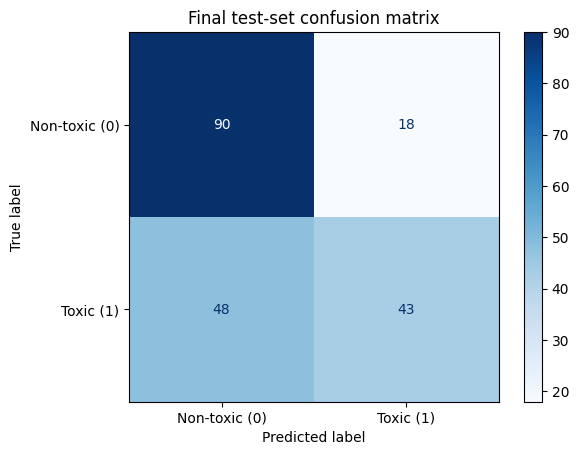

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

final_confusion_matrix = confusion_matrix(
    test_df["IsToxic"],
    test_predictions,
    labels=[0, 1],
)

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=["Non-toxic (0)", "Toxic (1)"],
)
confusion_display.plot(cmap="Blues", values_format="d")
plt.title("Final test-set confusion matrix")
plt.show()

### Final evaluation conclusion

The reported test F1 is an unbiased final estimate because the test labels were not used for feature selection, hyperparameter tuning, vocabulary construction, IDF estimation, or model training. All decisions were made using only the training set and its five cross-validation folds.

# Project Conclusion

This project implemented an end-to-end supervised text-classification flow for detecting toxic YouTube comments. A custom logistic-regression classifier was trained on TF-IDF representations, while grid search with stratified 5-fold cross-validation compared 48 combinations of preprocessing choices and hyperparameters. The selected configuration used stop-word removal, Porter stemming, unigrams, `C = 10`, and a learning rate of `0.5`, achieving a mean cross-validation F1 of `0.6309`. After retraining on the complete training set, the model achieved a held-out test F1 of `0.5658` for the toxic class.

The confusion matrix shows that the model correctly detected 43 toxic comments but missed 48, indicating that improving recall is an important direction for future work. The explainability analysis demonstrated that the model learned meaningful toxic-language indicators, but also revealed dataset-specific associations. Despite the moderate final score, the evaluation remains reliable because the test set was isolated from feature selection, TF-IDF fitting, hyperparameter tuning, and training.